In [ ]:
# Import Libraries
import numpy as np
import pandas as pd
from google.colab import files
import yfinance as yf

# Import Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Import Preprocessing
from sklearn.preprocessing import MinMaxScaler

# Import Selection
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

# Import Algoritma
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Import Metrics
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
# Mengunduh dan Load Dataset
TICKER = 'BNLI.JK'
df_main = yf.download(TICKER, period='max')

# Menghapus level 1 (BNLI.JK)
df_main.columns = df_main.columns.droplevel(1)

# Rename Kolom
df_main.columns = df_main.rename_axis(None, axis=1).columns

df_main.rename(columns={'Open': 'open',
                         'High': 'high',
                         'Low': 'low',
                         'Close': 'close',
                         'Volume': 'volume'}, inplace=True)

# Mengambil data dari tahun 2015 sampai 2025
# df_main = df_main.loc['2015':'2025']

# Cross Check Hasil rename
required_cols = ['open', 'low', 'high', 'close', 'volume']
df_main = df_main[required_cols].loc["2015":]

print(f"\n\nData {TICKER} berhasil diunduh. Total ukuran{df_main.shape}")

/tmp/ipython-input-4083487731.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_main = yf.download(TICKER, period='max')
[*********************100%***********************]  1 of 1 completed



Data BNLI.JK berhasil diunduh. Total ukuran(2681, 5)


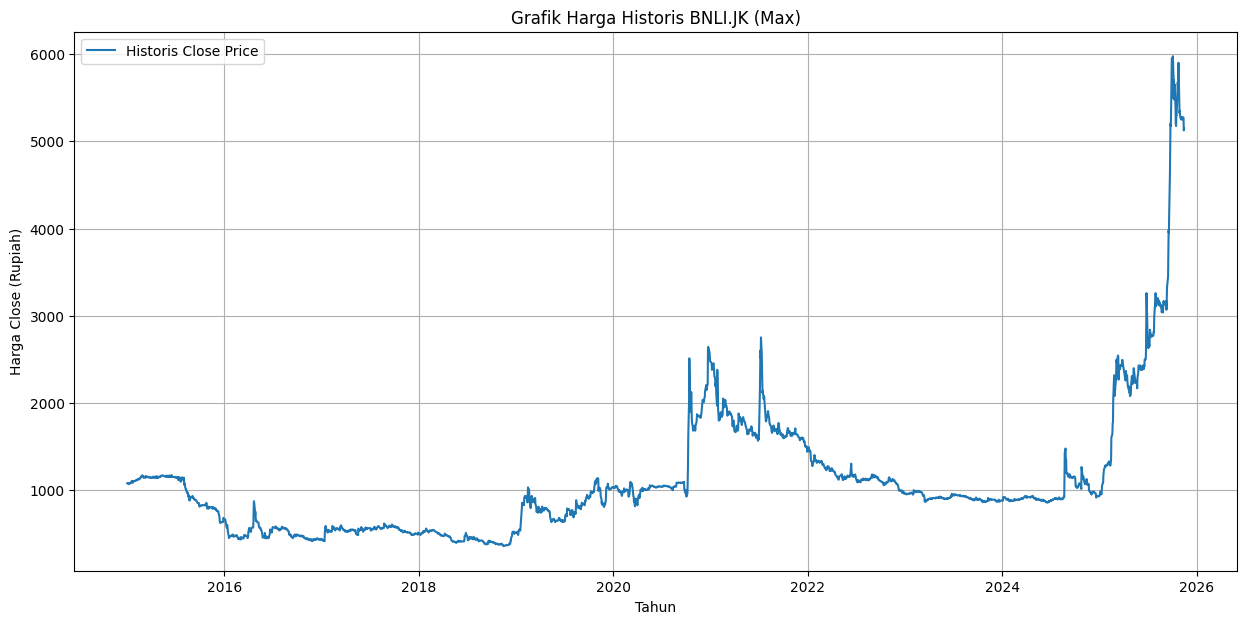

In [ ]:
# Visualisasi Data Historis
file_name = 'Grafik Historis.jpg'
plt.figure(figsize=(15, 7))
plt.plot(df_main.index, df_main['close'], label='Historis Close Price')
plt.title(f'Grafik Harga Historis {TICKER} (Max)')
plt.xlabel('Tahun')
plt.ylabel('Harga Close (Rupiah)')
plt.legend()
plt.grid(True)
plt.savefig(file_name)
plt.show()

In [ ]:
files.download(file_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df_copy = df_main.copy()

In [ ]:
# Set Index
df_copy.sort_index(inplace=True)

In [ ]:
df_copy

,open,low,high,close,volume
Date,,,,,
2015-01-02,1071.347027,1071.347027,1085.631720,1082.060547,872772
2015-01-05,1078.489380,1078.489380,1082.060553,1078.489380,1345996
2015-01-06,1071.346924,1071.346924,1078.489270,1071.346924,28948
2015-01-07,1078.489380,1078.489380,1099.916307,1078.489380,3390
2015-01-08,1078.489380,1078.489380,1078.489380,1078.489380,499695
...,...,...,...,...,...
2025-11-10,5275.000000,5225.000000,5300.000000,5250.000000,39200
2025-11-11,5275.000000,5200.000000,5300.000000,5275.000000,87500
2025-11-12,5300.000000,5250.000000,5300.000000,5250.000000,17500


In [ ]:
# Informasi Data
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2681 entries, 2015-01-02 to 2025-11-14
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   open    2681 non-null   float64
 1   low     2681 non-null   float64
 2   high    2681 non-null   float64
 3   close   2681 non-null   float64
 4   volume  2681 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 125.7 KB


In [ ]:
df_copy.describe()

,open,low,high,close,volume
count,2681.000000,2681.000000,2681.000000,2681.000000,2.681000e+03
mean,1093.659117,1073.998711,1114.696405,1093.862503,1.248988e+07
std,772.826388,748.013499,799.146163,776.235112,3.377752e+07
min,364.604094,359.677002,364.604094,359.677002,0.000000e+00
25%,570.720482,562.508670,578.932293,567.433167,8.310000e+04
50%,923.828064,912.883362,932.229735,922.492615,6.410500e+05
75%,1154.189142,1145.527466,1164.054011,1154.189209,9.996136e+06
max,6000.000000,5950.000000,6500.000000,5975.000000,4.794329e+08


In [ ]:
# Pengecekan nilai kosong
df_copy.isnull().sum()

,0
open,0
low,0
high,0
close,0
volume,0


In [ ]:
# Pembuatan Features Engineering

# Moving Average (MA)
df_copy['MA_50'] = df_copy['close'].rolling(window=50).mean()
df_copy['MA_200'] = df_copy['close'].rolling(window=200).mean()

# Relative Strength Index (RSI)
rsi_period = 14
delta = df_copy['close'].diff(1)
gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)

# Menggunakan EWM (Exponential Weighted Moving) untuk kalkulasi RSI standar
avg_gain = gain.ewm(com=rsi_period - 1, adjust=False).mean()
avg_loss = loss.ewm(com=rsi_period - 1, adjust=False).mean()
rs = avg_gain / avg_loss
df_copy['RSI'] = 100 - (100 / (1 + rs))

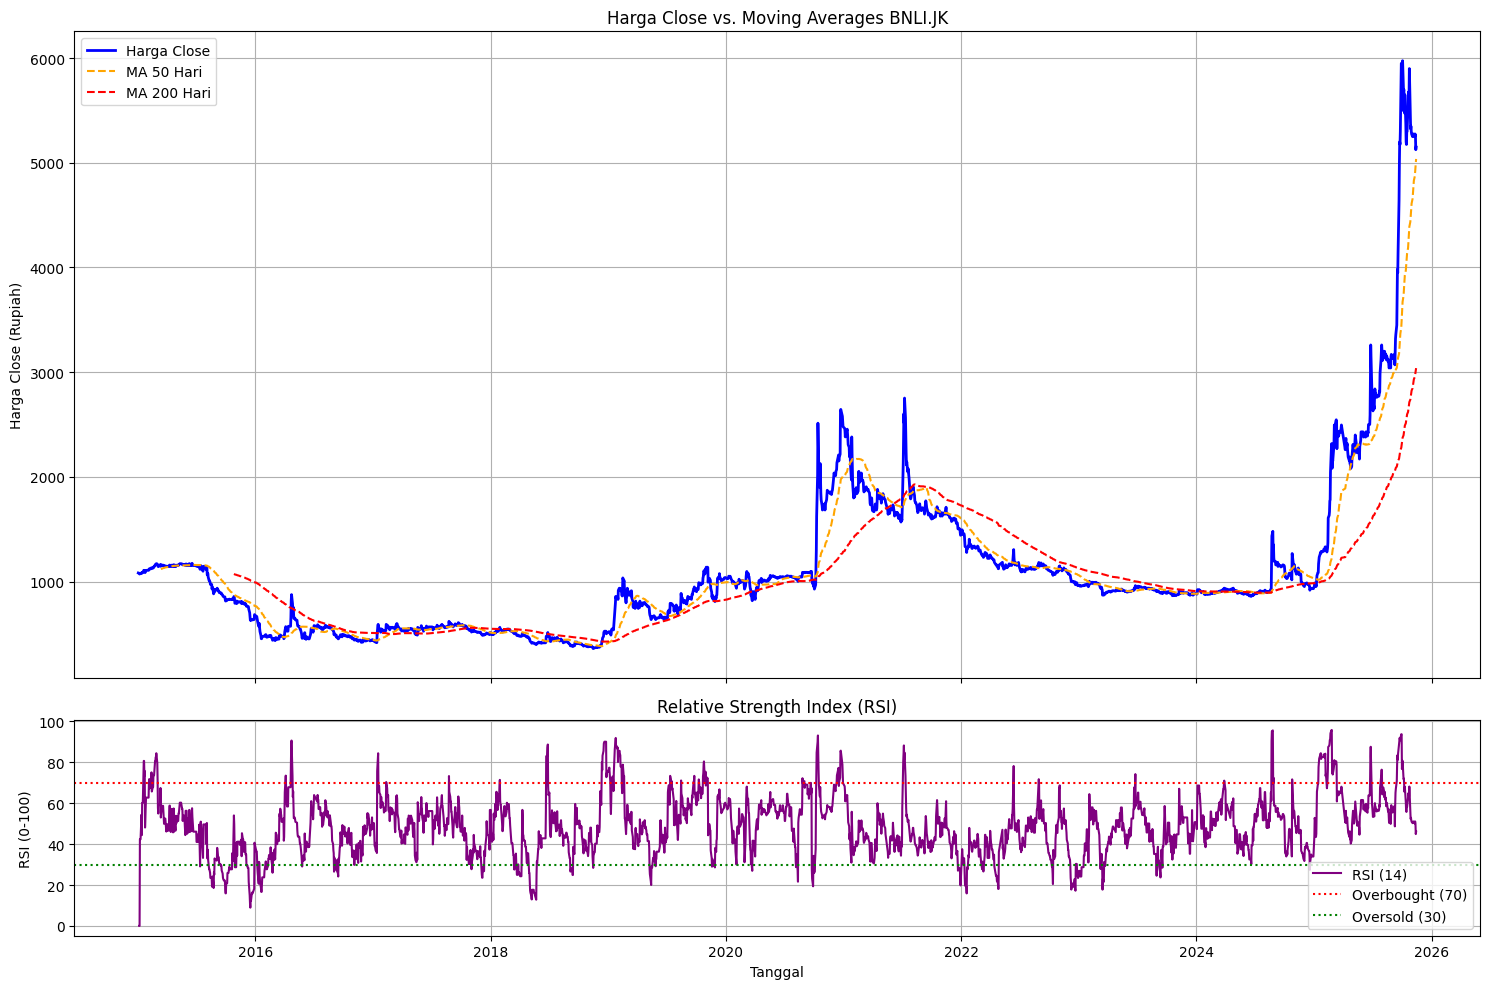

In [ ]:
# Visualisasi Fitur (MA & RSI)
file_name = 'MA & RSI.jpg'
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True,
                               gridspec_kw={'height_ratios': [3, 1]})

# Harga Close, MA_50, dan MA_200
ax1.plot(df_copy.index, df_copy['close'], label='Harga Close', color='blue', linewidth=2)
ax1.plot(df_copy.index, df_copy['MA_50'], label='MA 50 Hari', color='orange', linestyle='--')
ax1.plot(df_copy.index, df_copy['MA_200'], label='MA 200 Hari', color='red', linestyle='--')
ax1.set_title(f'Harga Close vs. Moving Averages {TICKER}')
ax1.set_ylabel('Harga Close (Rupiah)')
ax1.legend()
ax1.grid(True)

# RSI
ax2.plot(df_copy.index, df_copy['RSI'], label='RSI (14)', color='purple')

# Menambahkan garis Overbought/Jenuh Beli (70) dan Oversold/Jenuh Jual (30)
ax2.axhline(70, linestyle=':', color='red', label='Overbought (70)')
ax2.axhline(30, linestyle=':', color='green', label='Oversold (30)')
ax2.set_title('Relative Strength Index (RSI)')
ax2.set_ylabel('RSI (0-100)')
ax2.set_xlabel('Tanggal')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig(file_name)
plt.show()

In [ ]:
files.download(file_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Handle nilai NaN
df_copy.dropna(inplace=True)

In [ ]:
# Tentukan Prediksi (N Hari)
prediction_days = 1

# Membuat kolom target
df_copy['target'] = df_copy['close'].shift(-prediction_days)

In [ ]:
# Handle nilai NaN
df_copy.dropna(inplace=True)

In [ ]:
# Definisikan Feature (X) dan Target (Y)
features = ['open','high', 'low', 'close', 'volume', 'MA_50', 'MA_200', 'RSI']
target = 'target'

X = df_copy[features]
y = df_copy[target]

In [ ]:
# Simpan data untuk prediksi final untuk input LSTM
df_features_lstm = df_copy[features].copy()

# Simpan baris terakhir untuk Random Forest dan KNN
df_future = df_copy.iloc[-1].copy()

In [ ]:
# Pisahkan data latih dan data uji (Untuk RFR dan KNN)
train_size = int(len(X) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

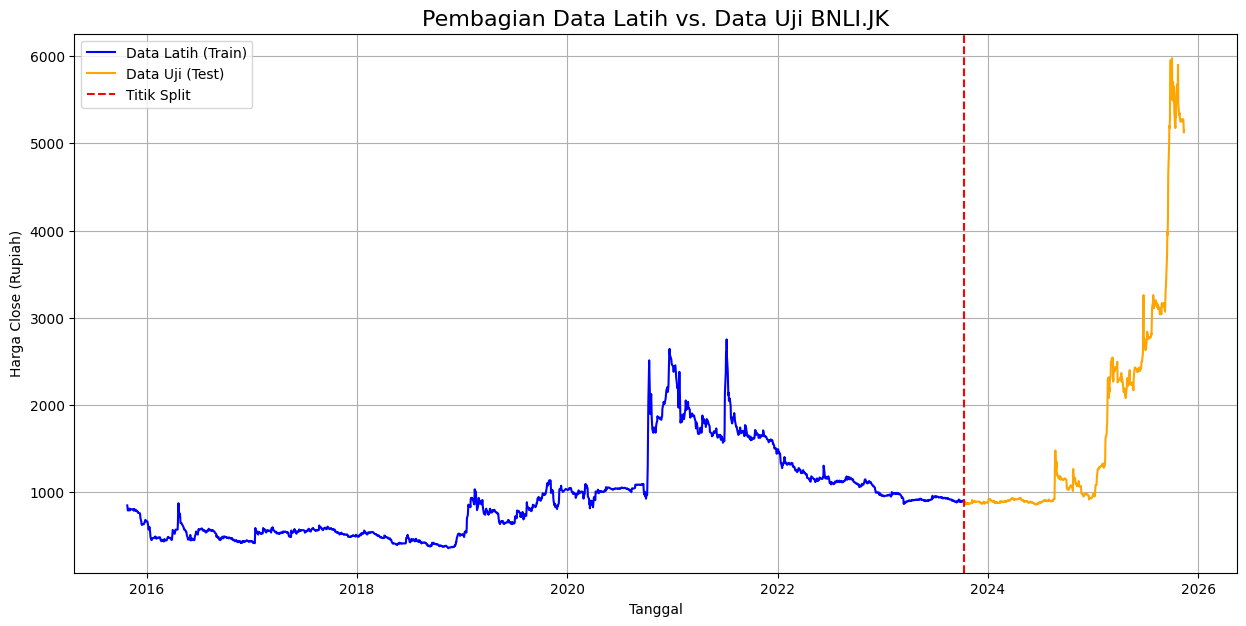

In [ ]:
# Visualisasi Train/Test Split
file_name = 'Pembagian Data Uji & Data Latih.jpg'
plt.figure(figsize=(15, 7))
plt.plot(y_train.index, y_train, label='Data Latih (Train)', color='blue')
plt.plot(y_test.index, y_test, label='Data Uji (Test)', color='orange')
plt.axvline(y_test.index[0], color='red', linestyle='--', label='Titik Split') # Garis pemisah
plt.title(f'Pembagian Data Latih vs. Data Uji {TICKER}', fontsize=16)
plt.xlabel('Tanggal')
plt.ylabel('Harga Close (Rupiah)')
plt.legend()
plt.grid(True)
plt.savefig(file_name)
plt.show()

In [ ]:
files.download(file_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Definisikan y_test aktual untuk evaluasi diakhir
y_test_actual = y_test.values

In [ ]:
# Ukuran Data setelah dilakukan splitting
print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}, y_test shape: {y_test.shape}")

X_train shape: (1984, 8), X_test shape: (497, 8)
y_train shape: (1984,), y_test shape: (497,)


In [ ]:
# Scalling untuk X dan Y
scaler_X = MinMaxScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

scaler_y = MinMaxScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))

In [ ]:
# Menyiapkan dictionary untuk menyimpan hasil model
model_result = {}

In [ ]:
# Modelling Algoritma Random Forest

# Cross-Validaion Time Series
tscv = TimeSeriesSplit(n_splits=5)

# Parameter
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# RandomizeSearchCV
rf_random = RandomizedSearchCV(
    estimator = RandomForestRegressor(random_state=42),
    param_distributions = param_grid_rf,
    n_iter = 10,
    cv = tscv,
    verbose=0,
    random_state=42,
    n_jobs = -1,
    scoring = 'neg_root_mean_squared_error'
)

rf_random.fit(X_train_scaled, y_train_scaled.ravel())
best_rf = rf_random.best_estimator_
print("Tuning Selesai")

# Evaluasi Model Random Forest
y_pred_scaled_rf = best_rf.predict(X_test_scaled)
y_pred_rf = scaler_y.inverse_transform(y_pred_scaled_rf.reshape(-1, 1)).ravel()
rmse_rf = np.sqrt(mean_squared_error(y_test_actual, y_pred_rf))
r2_rf = r2_score(y_test_actual, y_pred_rf)

# Simpan hasil model
model_result['Random Forest'] = {'RMSE': rmse_rf, 'R2': r2_rf, "Preds":y_pred_rf}


Tuning Selesai


In [ ]:
# Modelling Algoritma KNN

# Parameter
param_grid_knn = {'n_neighbors' : [3, 5, 7, 10, 15, 20],
                  'weights' : ['uniform', 'distance'],
                  }

knn_random = RandomizedSearchCV(
    estimator = KNeighborsRegressor(),
    param_distributions = param_grid_knn,
    n_iter = 10,
    cv = tscv,
    verbose=0,
    random_state=42,
    n_jobs = -1,
    scoring = 'neg_root_mean_squared_error'
)

knn_random.fit(X_train_scaled, y_train_scaled.ravel())
best_knn = knn_random.best_estimator_
print("Tuning Selesai")

# Evaluasi KNN
y_pred_scaled_knn = best_knn.predict(X_test_scaled)
y_pred_knn = scaler_y.inverse_transform(y_pred_scaled_knn.reshape(-1, 1)).ravel()
rmse_knn = np.sqrt(mean_squared_error(y_test_actual, y_pred_knn))
r2_knn = r2_score(y_test_actual, y_pred_knn)

# Simpan hasil model
model_result['KNN'] = {'RMSE': rmse_knn, 'R2': r2_knn, "Preds":y_pred_knn}


Tuning Selesai


In [ ]:
# Mempersiapkan kebutuhan untuk LSTM

# Definisikan Time Steps
n_steps = 60
n_features = len(features)

# Membuat Fungsi sequences
# Menggunakan 60 hari data untuk memprediksi hari ke 61
def create_sequences(X_data: list, y_data: list, time_steps=n_steps):
  X_lstm, y_lstm = [], []
  for i in range(time_steps, len(X_data)):
    X_lstm.append(X_data[i-time_steps:i, :])
    y_lstm.append(y_data[i])
  return np.array(X_lstm), np.array(y_lstm)

In [ ]:
# Preprocessing Long Short-Term Memory

# Membuat X_train_lstm dan y_train_lstm
X_train_lstm, y_train_lstm = create_sequences(X_train_scaled, y_train_scaled.ravel(), n_steps)

# Menggabungkan X_train (akhir) dan X_test
X_test_input = np.concatenate(
    (X_train_scaled[-n_steps:], X_test_scaled), axis = 0
    )

# Menggabungkan y_train (akhir) dan y_test
y_test_targets = np.concatenate(
    (y_train_scaled[-n_steps:], y_test_scaled), axis = 0
    )

# Membuat X_test_lstm dan y_test_lstm
X_test_lstm, y_test_lstm = create_sequences(X_test_input, y_test_targets.ravel(), n_steps)

In [ ]:
# Ukuran data setelah dilakukan preprocessing
print(f"Ukuran data LSTM")
print(f"X_train_lstm shape: {X_train_lstm.shape}, X_test_lstm shape: {X_test_lstm.shape}")
print(f"y_train_lstm shape: {y_train_lstm.shape}, y_test_lstm shape: {y_test_lstm.shape}")

Ukuran data LSTM
X_train_lstm shape: (1924, 60, 8), X_test_lstm shape: (497, 60, 8)
y_train_lstm shape: (1924,), y_test_lstm shape: (497,)


In [ ]:
# Membangun Arsitektur Model LSTM
lstm_model = Sequential([
    LSTM(units=50, return_sequences=True, input_shape=(n_steps, n_features),
         recurrent_dropout=0.2),
    Dropout(0.2),
    LSTM(units=50, return_sequences=False, recurrent_dropout=0.2),
    Dropout(0.2),
    Dense(units=25),
    Dense(1)
    ])

lstm_model.compile(optimizer='adam', loss='mean_squared_error')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# Melatih model LSTM
history = lstm_model.fit(
    X_train_lstm, y_train_lstm,
    batch_size=32,
    epochs=50,
    validation_data=(X_test_lstm, y_test_lstm),
    verbose=0,
    shuffle=False
)

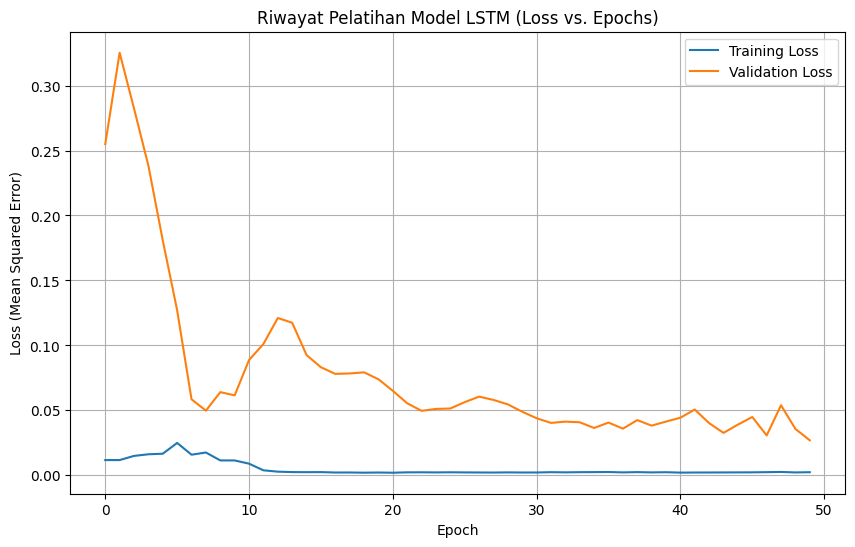

In [ ]:
# Visualisasi Riwayat Training LSTM
file_name = 'Riwayat_Pelatihan_LSTM.jpg'
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Riwayat Pelatihan Model LSTM (Loss vs. Epochs)')
plt.ylabel('Loss (Mean Squared Error)')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)
plt.savefig(file_name)
plt.show()

In [ ]:
files.download(file_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Evaluasi Model LSTM
y_pred_scaled_lstm = lstm_model.predict(X_test_lstm, verbose=0)
y_pred_lstm = scaler_y.inverse_transform(y_pred_scaled_lstm).ravel()

rmse_lstm = np.sqrt(mean_squared_error(y_test_actual, y_pred_lstm))
r2_lstm = r2_score(y_test_actual, y_pred_lstm)

model_result['LSTM'] = {'RMSE': rmse_lstm, 'R2': r2_lstm, 'Preds': y_pred_lstm}

In [ ]:
# Evaluasi dan Perbandingan Model
result = pd.DataFrame(model_result).T
result = result[['RMSE', 'R2']]
result['RMSE'] = result['RMSE'].round(2)
result['R2'] = (result['R2']*100).round(2)
result = result.sort_values(by='RMSE', ascending=True)

print("==== Hasil Perbandingan Model ====")
print(result.to_markdown(floatfmt=".2f"))

==== Hasil Perbandingan Model ====
|               |   RMSE |    R2 |
|:--------------|-------:|------:|
| LSTM          | 392.88 | 91.22 |
| Random Forest | 874.91 | 56.45 |
| KNN           | 882.98 | 55.65 |


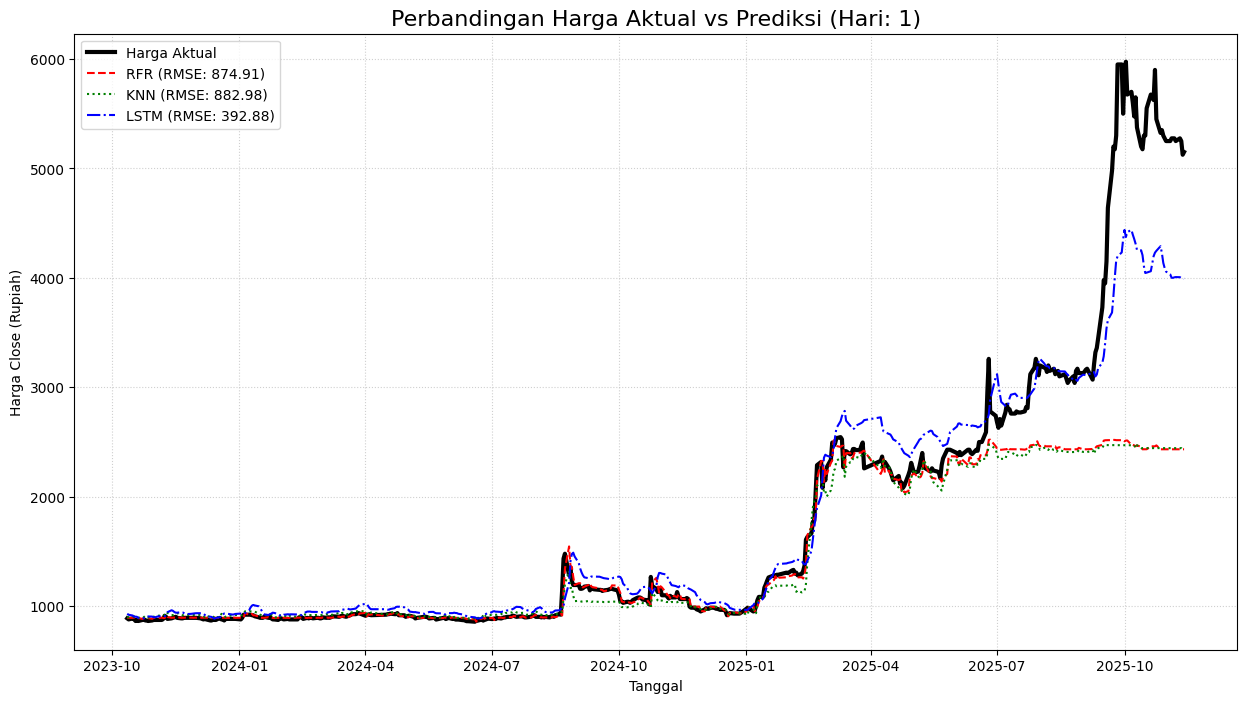

In [ ]:
# Plot Hasil Prediksi vs Aktual
file_name = 'Visualisasi_Hasil.jpg'
plt.figure(figsize=(15,8))
plt.title(f"Perbandingan Harga Aktual vs Prediksi (Hari: {prediction_days})", fontsize=16)

# Index untuk plot
index_rf_knn = y_test.index
index_lstm = y_test.index

plt.plot(index_rf_knn, y_test_actual, label='Harga Aktual', color='black', linewidth=3)
plt.plot(index_rf_knn, y_pred_rf, label=f"RFR (RMSE: {rmse_rf:.2f})", color='red', linestyle='--')
plt.plot(index_rf_knn, y_pred_knn, label=f"KNN (RMSE: {rmse_knn:.2f})", color='green', linestyle=':')
plt.plot(index_lstm, y_pred_lstm, label=f"LSTM (RMSE: {rmse_lstm:.2f})", color='blue', linestyle='-.')
plt.xlabel('Tanggal')
plt.ylabel('Harga Close (Rupiah)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.savefig(file_name)
plt.show()


In [ ]:
files.download(file_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Proses Prediksi Harga Besok
print(f"==== Prediksi Harga Saham Besok ({prediction_days}) Hari ke Depan ===")

# Data Hari Ini (baris terakhir yang punya fitur lengkap)
current_price = df_future['close']
current_date = df_future.name.date()
current_feature = df_future[features].values.reshape(1, -1)

print("Data Hari Ini:")
print(f"Data terakhir diambil pada tanggal: {current_date}")
print(f"Harga Close saat ini: {current_price:,.0f}")
print("="*53)

==== Prediksi Harga Saham Besok (1) Hari ke Depan ===
Data Hari Ini:
Data terakhir diambil pada tanggal: 2025-11-13
Harga Close saat ini: 5,125


In [ ]:
# Prediksi Random Forest dan KNN
feature_scaled_rf_knn = scaler_X.transform(current_feature)

# Random Forest
pred_rf_scaled = best_rf.predict(feature_scaled_rf_knn)
pred_rf_next = scaler_y.inverse_transform(pred_rf_scaled.reshape(-1, 1))[0][0]
condition_rf = "Naik" if pred_rf_next > current_price else "Turun"

# KNN
pred_knn_scaled = best_knn.predict(feature_scaled_rf_knn)
pred_knn_next = scaler_y.inverse_transform(pred_knn_scaled.reshape(-1, 1))[0][0]
condition_knn = "Naik" if pred_knn_next > current_price else "Turun"

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [ ]:
# Prediksi LSTM
all_feature_scaled = scaler_X.transform(df_features_lstm)
last_sequence = all_feature_scaled[-n_steps:]
last_sequence_reshaped = last_sequence.reshape(-1, n_steps, n_features)

pred_lstm_scaled = lstm_model.predict(last_sequence_reshaped, verbose=0)
pred_lstm_next = scaler_y.inverse_transform(pred_lstm_scaled)[0][0]
condition_lstm = "Naik" if pred_lstm_next > current_price else "Turun"

In [ ]:
# Hasil Prediksi
print(f"Prediksi Model Random Forest:")
print(f"Harga Besok: {pred_rf_next:,.0f}")
print(f"Sinyal: {condition_rf} (Dibandingkan harga {current_price:,.0f})\n")

print(f"Prediksi Model KNN:")
print(f"Harga Besok: {pred_knn_next:,.0f}")
print(f"Sinyal: {condition_knn} (Dibandingkan harga {current_price:,.0f})\n")

print(f"Prediksi Model LSTM:")
print(f"Harga Besok: {pred_lstm_next:,.0f}")
print(f"Sinyal: {condition_lstm} (Dibandingkan harga {current_price:,.0f})\n")


Prediksi Model Random Forest:
Harga Besok: 2,434
Sinyal: Turun (Dibandingkan harga 5,125)

Prediksi Model KNN:
Harga Besok: 2,426
Sinyal: Turun (Dibandingkan harga 5,125)

Prediksi Model LSTM:
Harga Besok: 3,955
Sinyal: Turun (Dibandingkan harga 5,125)

